In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "3"

import jax
print(f"JAX devices: {jax.devices()}")

from importlib import reload
from importlib.resources import files, as_file

import numpy as np
import jax
import recovar
from recovar import (
    plot_utils, 
    output,
    simulator,
    utils,
    dataset,
    em,
    regularization, 
    synthetic_dataset,
    utils,
    noise

)
import time
import matplotlib.pyplot as plt
import seaborn as sns

reload(simulator)

# Dataset parameters
grid_size = 64
n_images = 10000
generate_data = True
noise_level = 0.1

# Input/output paths
volume_folder_input = str(files(recovar) / "data" / "vol")
output_folder = "/tmp/em_test/"

# Dataset generation parameters
volume_distribution = None #np.array([1, 0, 0])
voxel_size = 4.25 * 128 / grid_size

# Create output directory
output.mkdir_safe(output_folder)

if generate_data:
    image_stack, sim_info = simulator.generate_synthetic_dataset(output_folder, voxel_size, volume_folder_input, n_images,
                                                                    outlier_file_input = None, grid_size = grid_size,
                                    volume_distribution = volume_distribution,  dataset_params_option = "uniform", noise_level = noise_level,
                                    noise_model = "white", put_extra_particles = False, percent_outliers = 0.00, 
                                    volume_radius = 0.7, trailing_zero_format_in_vol_name = True, noise_scale_std =0, contrast_std = 0  , disc_type = 'nearest', n_tilts = -1 )
    print(f"Finished generating dataset {output_folder}")


ModuleNotFoundError: No module named 'jax'

In [ ]:
# Set up rotations and translation grids
healpix_order = 3
angles = em.sampling.get_rotation_grid(healpix_order)
rotation_grid = utils.R_from_relion(angles)
translation_grid = em.sampling.get_translation_grid(2, 1)

# Load dataset
dataset_dict = dataset.get_default_dataset_option()
dataset_dict.update({
    'ctf_file': output_folder + "ctf.pkl",
    'poses_file': output_folder + "poses.pkl", 
    'particles_file': f"{output_folder}particles.{grid_size}.mrcs"
})
cryo = dataset.load_dataset_from_dict(dataset_dict, lazy=False)

# Load ground truth data
sim_info = utils.pickle_load(output_folder + '/simulation_info.pkl')
gt_recon = synthetic_dataset.load_heterogeneous_reconstruction(sim_info)
gt_vol = gt_recon.volumes
noise_variance = sim_info['noise_variance']

# Get mean volume and signal variance
gt_results = synthetic_dataset.load_heterogeneous_reconstruction(sim_info)
mean_estimate = gt_results.get_mean()
# signal_variance_radial = regularization.average_over_shells(np.abs(gt_vol)**2, gt_results.volume_shape) 
# signal_variance = utils.make_radial_image(signal_variance_radial, gt_results.volume_shape)

ind_split = [np.arange(n_images//2), np.arange(n_images//2, n_images)]
del dataset_dict['ind']
cryos = dataset.get_split_datasets_from_dict(dataset_dict, ind_split, False)

for cryo in cryos:
    cryo.set_radial_noise_model(noise_variance)


In [ ]:
import jax.numpy as jnp
U_initial, s_initial, _ = gt_results.get_vol_svd() 
U_initial = U_initial[:,:-1]
s_initial = s_initial[:-1]
# Square root of covar
W_initial = U_initial * s_initial[None]

w_gt_averaged = regularization.batch_average_over_shells(jnp.abs(W_initial.T)**2, gt_results.volume_shape, 0 )
W_prior = utils.batch_make_radial_image(w_gt_averaged, gt_results.volume_shape, True).T


In [ ]:
# options = utils.make_algorithm_options(args)


In [ ]:
from recovar import covariance_estimation, homogeneous, principal_components
reload(covariance_estimation)
def make_algorithm_options():
    options = {'volume_mask_option': None,
    'zs_dim_to_test': [10,],
    'contrast' : "none",
    'ignore_zero_frequency' : False ,
    'keep_intermediate' : False ,
    }
    return options
valid_idx = cryo.get_valid_frequency_indices()

options = make_algorithm_options()
batch_size = 500
noise_variance = utils.make_radial_image(noise_variance, cryos[0].image_shape)
covariance_options = covariance_estimation.get_default_covariance_computation_options(cryos[0].grid_size)
means, mean_prior, _  = homogeneous.get_mean_conformation_relion(cryos, 2*batch_size, noise_variance = noise_variance,  use_regularization = False)
variance_est, _, variance_fsc, _, noise_p_variance_est = covariance_estimation.compute_variance(cryos, mean_estimate, batch_size//2, None, use_regularization = True, disc_type = 'cubic')

u = {}
s = {}


focus_mask = np.ones(cryos[0].volume_shape)
dilated_volume_mask = np.ones(cryos[0].volume_shape)
u_this,s_this, covariance_cols, picked_frequencies, column_fscs = principal_components.estimate_principal_components(cryos, options, means, mean_prior, focus_mask, dilated_volume_mask, valid_idx, batch_size, gpu_memory_to_use=40, covariance_options = covariance_options, variance_estimate = variance_est['combined'], use_reg_mean_in_contrast = False)
u_covar = u_this['rescaled']
s_covar = s_this['rescaled']

W_prior_from_covar = u_covar * np.sqrt(s_covar)[None]

--------------------------------
--------------------------------
mask_images_in_proj changed
mask_images_in_proj changed
--------------------------------
--------------------------------


Applying mask in post_proces_from_filter_v2


In [ ]:
from recovar import ppca
from recovar import fourier_transform_utils 
ftu = fourier_transform_utils.fourier_transform_utils(jnp)


reload(ppca)
W_initial = np.random.randn(*W_prior.shape).T
W_initial = W_initial.reshape(W_initial.shape[0], *cryos[0].volume_shape)
W_initial = ftu.get_dft3(W_initial).reshape(W_initial.shape[0], -1).T

# u_ppca, s_ppca, W, expected_zs, second_moment_zs = ppca.EM(cryos, mean_estimate, W_initial , W_prior * 1e-1 )

for k in np.arange(-4, 4):
    u_ppca, s_ppca, W, expected_zs, second_moment_zs = ppca.EM(cryos, mean_estimate, W_initial , W_prior * 10**(-k) )
    u['ppca_'+str(k)] = u_ppca
    s['ppca_'+str(k)] = s_ppca



np.mean(expected_zs, axis=0), np.var(expected_zs, axis=0) [ 3.22098256e-05-3.30928843e-06j -1.79722527e-05+4.03199677e-06j] [5.10904058e-06 4.99097344e-06]
Done with EM step 0
np.mean(expected_zs, axis=0), np.var(expected_zs, axis=0) [ 0.00022471-1.42621154e-06j -0.00038092-3.62412799e-06j] [8.26225622e-05 4.02636808e-04]
Done with EM step 1
np.mean(expected_zs, axis=0), np.var(expected_zs, axis=0) [ 0.00086438-3.14684454e-06j -0.00095572-3.64902108e-07j] [0.00020994 0.00087349]
Done with EM step 2
np.mean(expected_zs, axis=0), np.var(expected_zs, axis=0) [ 0.00282943-4.41055397e-06j -0.00280533+3.77327623e-06j] [0.00036624 0.00107934]
Done with EM step 3
np.mean(expected_zs, axis=0), np.var(expected_zs, axis=0) [ 0.00629427-5.66250918e-06j -0.00604942+5.83384196e-06j] [0.00050723 0.00125502]
Done with EM step 4
np.mean(expected_zs, axis=0), np.var(expected_zs, axis=0) [ 0.01114125-6.45255689e-06j -0.01041655+6.76664220e-06j] [0.00060394 0.00139276]
Done with EM step 5
np.mean(expected

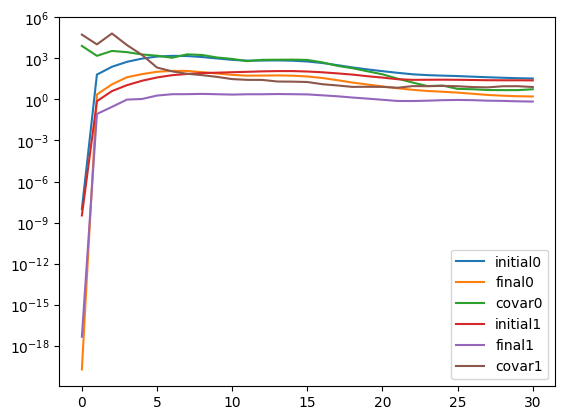

In [ ]:
# w_gt_averaged = regularization.batch_average_over_shells(jnp.abs(W_initial.T)**2, gt_results.volume_shape, 0 )
W_averaged = regularization.batch_average_over_shells(jnp.abs(W.T)**2, gt_results.volume_shape, 0 )
W_prior_from_covar_averaged = regularization.batch_average_over_shells(jnp.abs(W_prior_from_covar.T)**2, gt_results.volume_shape, 0 )


for i in range(2):
    # plt.figure()
    # plt.semilogy(W_prior[i], label = 'prior' + str(i)   )
    plt.semilogy(w_gt_averaged[i], label = 'initial' + str(i)   )
    plt.semilogy(W_averaged[i], label = 'final' + str(i))
    plt.semilogy(W_prior_from_covar_averaged[i], label = 'covar' + str(i))
plt.legend()
plt.show()


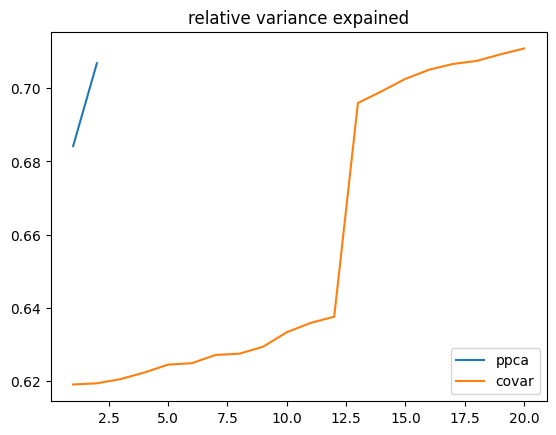

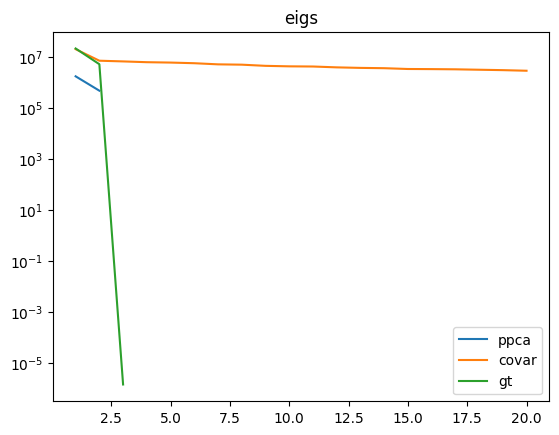

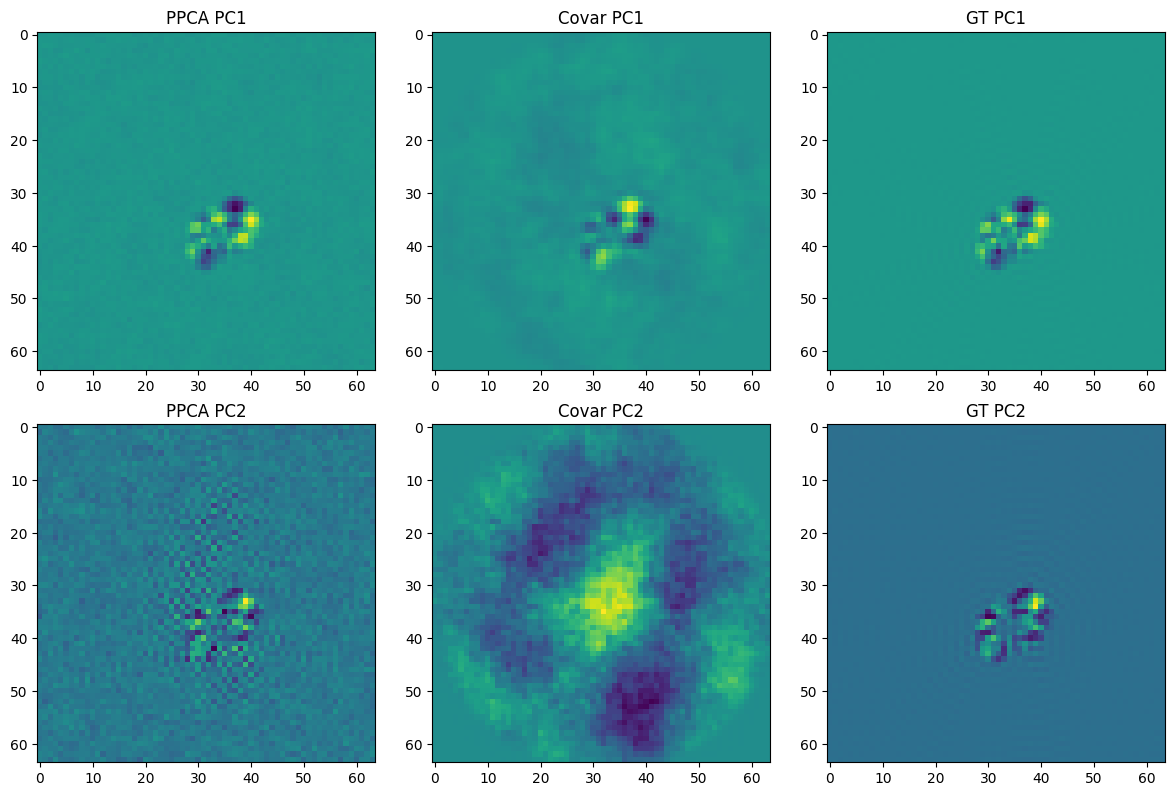

In [ ]:
# Load results


# load ground turths
# sim_directory = f"/home/mg6942/recovar/little_dataset/"
# reload(synt)
synt = synthetic_dataset.load_heterogeneous_reconstruction(output_folder + 'simulation_info.pkl')
u_gt, s_gt, vh = synt.get_vol_svd(contrasted = False, real_space = False, random_svd_pcs = 200)
s_gt = s_gt**2


from recovar import output
import numpy as np
import recovar
k =0 
take_n_pcs = 20

# u['ppca'] = u_ppca
# s['ppca'] = s_ppca

u['covar'] = u_covar
s['covar'] = s_covar

# Compute error metrics and plot
angles = {}
rel_var = {}
norm_var = {}

from recovar import metrics
import matplotlib.pyplot as plt
u['gt'] = u_gt
s['gt'] = s_gt
for key in u:
    if key == 'gt':
        continue
    angles[key] = recovar.metrics.subspace_angles(u_gt ,u[key], max_rank = 20)
    variance, rel_var[key], norm_var[key] = metrics.get_all_variance_scores(u[key], u_gt, s_gt)

b = 20
def plot_dict(u_dict, title, max_size = b, log_scale = False):
    plt.figure()
    for key in u_dict.keys():
        max_size_this = np.min([max_size, u_dict[key].size])
        plt.plot(np.arange(1, max_size_this+1), u_dict[key][:max_size_this], label = key)
    plt.legend()
    plt.title(title)
    if log_scale:
        plt.yscale('log')

# plot_dict(angles, 'angle error')
plot_dict(rel_var, 'relative variance expained')
# plot_dict(norm_var, 'normalized variance expained')
plot_dict(s, 'eigs', log_scale = True)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# Plot PPCA components
axes[0,0].imshow(cryos[0].get_proj(u['ppca'][:,0].reshape(-1)))
axes[0,0].set_title('PPCA PC1')
axes[1,0].imshow(cryos[0].get_proj(u['ppca'][:,1].reshape(-1)))
axes[1,0].set_title('PPCA PC2')

# Plot Covariance components 
axes[0,1].imshow(cryos[0].get_proj(u['covar'][:,0].reshape(-1)))
axes[0,1].set_title('Covar PC1')
axes[1,1].imshow(cryos[0].get_proj(u['covar'][:,1].reshape(-1)))
axes[1,1].set_title('Covar PC2')

# Plot Ground truth components
axes[0,2].imshow(cryos[0].get_proj(u['gt'][:,0].reshape(-1)))
axes[0,2].set_title('GT PC1')
axes[1,2].imshow(cryos[0].get_proj(u['gt'][:,1].reshape(-1)))
axes[1,2].set_title('GT PC2')

plt.tight_layout()
plt.show()


In [ ]:
cryos[0].get_proj(u[:,0].reshape(-1))

In [ ]:
import pywt



In [3]:
!pip install jaxopt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 9.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 MB 12.8 MB/s  0:00:04m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 667.4/667.4 kB 8.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 10.7 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [jaxopt]2m4/6 [jax]ib]


In [6]:
import pyproximal


In [7]:
import jaxopt   

In [9]:
pyproximal.l1

AttributeError: module 'pyproximal' has no attribute 'l1'

In [12]:
pyproximal.L1.prox()

TypeError: L1._increment_count.<locals>.wrapped() missing 1 required positional argument: 'self'

In [15]:


pyproximal.L1.prox(z)



AttributeError: 'numpy.ndarray' object has no attribute 'count'

In [ ]:
import numpy as np
z = np.random.randn(10)
pyproximal.L1().prox(z, 0.1)




In [ ]:
from pyproximal import ProxOperator
class LeastSquareFromNormalEqs(ProxOperator):
    from recovar import linalg
    r"""Proximal operator for \sum_i 0.5 * \|P_i x - b\|_2^2, where \sum P_i^* P_i and \sum P_i^* b are precomputed
    """
    def __init__(self, dim, R, M):
        super().__init__(None, False)
        self.dim = dim
        self.lhs = lhs
        self.rhs = rhs

    def __call__(self, x):
        X = x.reshape(self.dim)
        # Compute \|Ax - y\|_2^2 = x^TA^TA^x - 2x.T @ A.T b + y^Ty^2
        return 0.5 * (jnp.dot(jnp.conj(x), self.lhs @ x) - 2 * jnp.dot(x, self.rhs ))

    @_check_tau
    def prox(self, x, tau):
        block_size = self.lhs.shape[-1]
        lhs_this = self.lhs *  + jnp.eye(block_size)[None]
        # W = linalg.batch_linear_solver(lhs_summed, rhs_summed[...,None])[...,0]

        rhs_this = tau * self.rhs + x
        y =  linalg.batch_linear_solver(lhs_this, rhs_this[...,None])[...,0]

        # X = x.reshape(self.dim)
        # Y = np.zeros_like(X)
        # for f, Rf in enumerate(self.R):
        #     Y[3 * f: 3 * f + 3, :] = np.linalg.solve(
        #         tau * Rf.T @ Rf + np.eye(3),
        #         tau * Rf.T @ self.M[2 * f:2 * f + 2, :] + X[3 * f: 3 * f + 3, :]
        #     )

        return y


class WaveletL1(ProxOperator):
    r"""Proximal operator for the stacked nuclear norm."""
    def __init__(self, dim, sigma=1.):
        super().__init__(dim, sigma)
        self.unstacked_dim = (dim[0] * 3, dim[1] // 3)
        self.wavelet = None

    def __call__(self, x):
        # X = np.linalg.norm( wavelet.to_basis(x),ord=1)
        return np.linalg.norm(self.wavelet.to_basis(x),ord=1)

    def prox(self, x, tau):
        x = self.wavelet.to_basis()
        # X = stack(x.reshape(self.unstacked_dim))
        x = super().prox(X.ravel(), tau)
        x = self.wavelet.to_imagee()
        return x


# def WaveletL1(ProxOperator):

ModuleNotFoundError: No module named 'recovar'

In [ ]:
import numpy as np
b = 10
n = 10
rhs = np.random.randn(b, n)
lhs = np.random.randn(b,n,n)



In [25]:
256**3 * 4 * 20**2 /1e9 /2

13.4217728

In [19]:
r"""
Non-rigid structure-from-motion (NRSfM)
=======================================
In computer vision, structure-from-motion (SfM) is an imaging technique for
estimating three-dimensional structures from two-dimensional images. Theoretically,
the problem is generally well-posed when considering rigid objects, meaning
that the objects do not move or deform in the scene. However, non-static scenes
are still relevant and have gained increased popularity among researchers in
recent years. This is known as *non-rigid structure-from-motion*.

In this tutorial, we will consider motion capture (MOCAP). This is a special
case, where we use images from multiple camera views to compute the 3D positions
of specifically designed markers that track the motion of a person (or object)
performing various tasks.

Non-rigid shapes
****************
To make the problem well-posed, one has to control the complexity of
the deformations using some minor assumptions on the possible space of object
shapes. This is not a weird thing to do: consider e.g. the human body,
we have different joints that bend and turn in a finite amount of ways; the
skeleton itself is rigid and not capable of such deformations. For this reason,
Bregler et al. [1]_ suggested that all movements (or shapes) can be represented
by a low-dimensional basis. In the context of motion capture, this means that
every movement a person does can be considered a combination of core movements
(or basis shapes).

Mathematically speaking, this translates to any motion being a linear combination
of the basis shapes, i.e. assuming there are :math:`K` basis shapes, any non-rigid
shape :math:`X_i` can be written as

    .. math::
        X_i = \sum_{i=1}^K c_{ik}B_k

where :math:`c_{ik}` are the basis coefficients and :math:`B_k` are the basis shapes.
Here, :math:`X_i` is a :math:`3\times N` matrix where each column is a point in
3D space.

The CMU MOCAP dataset
*********************
Let us first try to understand the data we are given. We will use the *Pickup*
instance from the CMU MOCAP dataset, which depicts a person picking something
up from the floor.
"""

# import matplotlib.pyplot as plt
# import matplotlib.animation as animation
import numpy as np
import scipy as sp


plt.close('all')
np.random.seed(0)
data = np.load('../testdata/mocap.npz', allow_pickle=True)
X_gt = data['X_gt']
markers = data['markers'].item()

###############################################################################
# First we view the first 3D poses. In order to easily visualize the person, we
# draw a skeleton between the markers corresponding to certain body parts. Note
# that these are not used in any other way.


def plot_first_3d_pose(ax, X, color='b', marker='o', linecolor='k'):
    ax.scatter(X[0, :], X[1, :], X[2, :], color, marker=marker)
    for j, ind in enumerate(markers.values()):
        ax.plot(X[0, ind], X[1, ind], X[2, ind], '-', color=linecolor)
    ax.set_box_aspect(np.ptp(X[:3, :], axis=1))
    ax.view_init(20, 25)


fig = plt.figure()
ax = fig.add_subplot(projection='3d')
plot_first_3d_pose(ax, X_gt)
plt.tight_layout()

###############################################################################
# Now, we turn the attention to the data the algorithm is given, which is a
# sequence of 2D images from varying views. The goal is to recreate the 3D
# points, such as in the example above, from all timestamps.

M = data['M']
F = int(X_gt.shape[0] / 3)


def _update(f: int):
    X = M[2 * f:2 * f + 2, :]
    lines[0].set_data(X[0, :], X[1, :])
    for j, ind in enumerate(markers.values()):
        lines[j + 1].set_data(X[0, ind], X[1, ind])
    return lines


fig, ax = plt.subplots()
lines = ax.plot([], [], 'r.')
for _ in range(len(markers)):
    lines.append(ax.plot([], [], 'k-')[0])
ax.set(xlim=(-2.5, 2.5), ylim=(-3.5, 3.5))
ax.set_aspect('equal')

ani = animation.FuncAnimation(fig, _update, F, interval=25, blit=True)


###############################################################################
# Note that these are the 2D image correspondences and that the image view is
# constantly changing as it is spinning around. Such motion can be modeled
# with orthographic cameras, which we will discuss next.
#
# Orthographic projections
# ************************
# Assuming that we know the pose of the camera from which the image was taken
# the corresponding 2D image point can be obtained. In the case of rotations,
# we assume the cameras are orthographic, meaning that the image points :math:`x_i`
# are obtained from the relation
#
#     .. math::
#         x_i = R_iX_i
#
# where :math:`R_i` is a :math:`2\times 3` matrix fulfilling :math:`R_iR_i^T=I`.
# Essentially, the :math:`R_i` matrices consists of the top two rows of the
# corresponding rotation matrix.
#
# Now, the task at hand is essentially the inverse problem: to reconstruct the
# 3D points for each point in time from these 2D images.
#
# Treating NRSfM as a low-rank factorization problem
# **************************************************
# One of the main novelties of the paper by Dai et al. [2]_ is to reshape and
# stack the non-rigid shapes :math:`X_i` in a way that allows us to treat the
# problem using methods from low-rank factorization. This is done in the following
# way: first concatenate all rows of :math:`X_i` creating a vector
# :math:`X^\sharp_i` of size :math:`1\times 3N`. Secondly, assuming there are in
# total :math:`F` non-rigid shapes we create the matrix :math:`X^\sharp` of size
# :math:`F\times 3N` by stacking all :math:`X^\sharp_i`. This enables us to decompose
# the newly created matrix :math:`X^\sharp=CB^\sharp` in the low-rank factors
# consisting of the shape coefficients :math:`C` and the basis shapes :math:`B^\sharp`
# (constructed in the same way as :math:`X^\sharp`).
#
# Now, let us implement and visualize this approach.


def stack(X: np.ndarray):
    return np.hstack((X[::3, :], X[1::3, :], X[2::3, :]))


Xi = np.arange(15).reshape((3, 5))
fig, ax = plt.subplots(1, 2)
ax[0].matshow(Xi)
ax[0].set_title(r'$X_i$')
ax[0].axis('off')
ax[1].matshow(stack(Xi))
ax[1].set_title(r'$X_i^\sharp$')
ax[1].axis('off')
plt.tight_layout()

###############################################################################
# Furthermore, we introduce the inverse
# operation, such that :math:`X=\mathcal{U}(X^\sharp)`, where
# :math:`\mathcal{U}` is the "unstacking" operator.


def unstack(Xs: np.ndarray):
    """Inverse operation of stack."""
    m, n = Xs.shape
    m *= 3
    n //= 3
    X = np.zeros((m, n), dtype=Xs.dtype)
    X[::3] = Xs[:, :n]
    X[1::3] = Xs[:, n:2*n]
    X[2::3] = Xs[:, 2*n:3*n]
    return X

###############################################################################
# In many cases, the necessary amount of basis shapes is not known
# *a priori*. Therefore, a suitable objective to try to minimize is
#
#     .. math::
#         \argmin_X \mu \rank(X^\sharp) + \frac{1}{2}\sum_{i=1}^F\|R_iX_i - x_i\|_2^2
#
# or, equivalently,
#
#     .. math::
#         \argmin_X \mu \rank(X^\sharp) + \frac{1}{2}\|RX - M\|_F^2
#
# where :math:`R` is a block-diagonal matrix with :math:`R_i` on the main diagonal,
# whereas :math:`X` and :math:`M` are the concatenations of :math:`X_i` and
# :math:`x_i`, respectively.
#
# Since the rank function is non-convex and discontinuous, it is often replaced
# by a relaxation. In [2]_ the *nuclear norm* :math:`\|\cdot\|_{*}` was used, i.e.
# we seek to minimize
#
#     .. math::
#         \argmin_X \mu \|X^\sharp\|_{*} + \frac{1}{2}\|RX - M\|_F^2 \; .
#
# There are some theoretical justifications for this specific choice of relaxation,
# e.g. the nuclear norm is the convex envelope of the rank function under
# curtain assumptions [3]_.
#
# Solving the relaxed problem
# ***************************
# We will now show how to solve this problem using splitting schemes. Specifically,
# we will use :class:`pyproximal.ADMM` and re-write the objective as
#
#     .. math::
#         \argmin_{X, Z} \mu \|Z^\sharp\|_{*} + \frac{1}{2}\|RX - M\|_F^2,
#
# and add the constraint :math:`X=Z`. This way, the proximal operators
# are simply those of the (stacked) nuclear norm and the Frobenius norm.
# We implement these next:

from pyproximal.ProxOperator import _check_tau
from pyproximal import Nuclear, ProxOperator


class BlockDiagFrobenius(ProxOperator):
    r"""Proximal operator for 1/2 * ||RX - M||_F^2 where R is block-diagonal.
    Note: You could also wrap pyproximal.L2, but this class is used here in
    this tutorial to increase legibility.
    """
    def __init__(self, dim, R, M):
        super().__init__(None, False)
        self.dim = dim
        self.R = R
        self.M = M

    def __call__(self, x):
        X = x.reshape(self.dim)
        return 0.5 * np.linalg.norm(self.R @ X - self.M, 'fro') ** 2

    @_check_tau
    def prox(self, x, tau):
        X = x.reshape(self.dim)
        Y = np.zeros_like(X)
        for f, Rf in enumerate(self.R):
            Y[3 * f: 3 * f + 3, :] = np.linalg.solve(
                tau * Rf.T @ Rf + np.eye(3),
                tau * Rf.T @ self.M[2 * f:2 * f + 2, :] + X[3 * f: 3 * f + 3, :]
            )
        return Y.flatten()


class StackedNuclear(Nuclear):
    r"""Proximal operator for the stacked nuclear norm."""
    def __init__(self, dim, sigma=1.):
        super().__init__(dim, sigma)
        self.unstacked_dim = (dim[0] * 3, dim[1] // 3)

    def __call__(self, x):
        X = stack(x.reshape(self.unstacked_dim))
        return super().__call__(X.ravel())

    def prox(self, x, tau):
        X = stack(x.reshape(self.unstacked_dim))
        x = super().prox(X.ravel(), tau)
        X = unstack(x.reshape(self.dim))
        return X.ravel()


###############################################################################
# Now we are ready to solve the problem using ADMM.

from pyproximal.optimization.primal import ADMM


mu = 1
R = data['R']
Rblk = sp.linalg.block_diag(*R)
M = Rblk @ X_gt
N = M.shape[1]
normal_size = (3*F, N)
stacked_size = (F, 3*N)
X0 = np.zeros(normal_size)
proxf = BlockDiagFrobenius(normal_size, R, M)
proxg = StackedNuclear(stacked_size, mu)
X_rec = ADMM(proxf, proxg, x0=X0.flatten(), tau=0.9, niter=200)[0]
X_rec = X_rec.reshape(normal_size)

###############################################################################
# Let us compare the results with the ground truth data.
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
plot_first_3d_pose(ax, X_gt)
plot_first_3d_pose(ax, X_rec, color='r', marker='v', linecolor='r')
plt.tight_layout()

###############################################################################
# Furthermore, we compute some statistics on the reconstruction performance. You
# can vary the regulation strength :math:`\mu` to see if you can achieve better
# performance yourself!
print(f'Datafit: {np.linalg.norm(Rblk @ X_rec - M, "fro")}')
print(f'Distance to GT: {np.linalg.norm(X_rec - X_gt, "fro")}')

###############################################################################
# One issue with the nuclear norm is that you have the hyperparameter
# :math:`\mu` that regulates the impact of the datafit vs. model assumption.
# When :math:`\mu=0` the datafit is perfect, but there would be no enforcement
# of the basis shapes, leading to severe over-fitting. On the other end, as
# :math:`\mu\to\infty` the reconstruction turns towards the zero matrix, thus
# completely ignoring the given data.
#
# Later publications have tried to mitigate this issue, and have shown that
# the weighted nuclear norm performs even better when the weights are selected
# with care [4]_. Other non-convex relaxations show similar results [5]_.
#
# **References**
#
# .. [1] C. Bregler, A. Hertzmann, and H. Biermann. Recovering non-rigid 3d shape
#    from image streams. In The IEEE Conference on Computer Vision and Pattern
#    Recognition (CVPR), 2000.
# .. [2] Y. Dai, H. Li, and M. He. A simple prior-free method for non-rigid
#    structure-from-motion factorization. International Journal of Computer Vision,
#    107(2):101–122, 2014.
# .. [3] M. Fazel, H. Hindi, and S. P. Boyd. A rank minimization heuristic with
#    application to minimum order system approximation. In the Proceedings of the
#    American Control Conference (ACC), 2001.
# .. [4] S. Kumar. Non-rigid structure from motion: Prior-free factorization method
#    revisited. In The IEEE Winter Conference on Applications of Computer Vision
#    (WACV), 2020.
# .. [5] M. Valtonen Örnhag and C. Olsson. A unified optimization framework for
#    low-rank inducing penalties. In the Proceedings of the IEEE/CVF conference
#    on computer vision and pattern recognition (CVPR), 2020.



NameError: name 'plt' is not defined